In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Multiple regression

Vi ønsker at fitte data ved brug af en model af formen
$$
y = \alpha + \beta_1x_1 + ... + \beta_d x_d 
$$
Bemærk, vi benytter også de binære variable i denne model, men de ender med bare at fungerer som interceptled hvis vi har at $x_2$ er binær har vi
\begin{align*}
x_2 = 0 \Rightarrow \\
y = \alpha  + \beta_1x_1 + \beta_2 x_2 
\end{align*}
eller vi har
\begin{align*}
x_2 = 1 \Rightarrow \\
y &= \alpha  + \beta_1x_1 + \beta_2 \cdot 1 \\
&= (\alpha + \beta_2) + beta_1 x_1
\end{align*}

Til at fitte modeller benytter vi scikit-learn


In [87]:
# load data
df = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv")
df["Complication"] = ((df["Risk_AlveolarOsteitis"] == 0) & 
                    (df["Risk_SecondaryInfection"] == 0) & 
                    (df["Risk_NerveDysesthesia"] == 0) & 
                    (df["Risk_Bleeding"] == 0)).astype(int)
df.columns

Index(['Client', 'Patient', 'Age', 'Sex', 'Pain', 'Swelling', 'Trismus',
       'Pericoronitis', 'Caries_Wisdom', 'Caries_Adjacent',
       'Periodontal_Status', 'Root_Development', 'Tooth_Mobility',
       'Tooth_Angulation', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count',
       'Root_Curvature', 'Bone_Density', 'Cyst', 'Diabetes', 'Osteoporosis',
       'Clotting_Disorder', 'Smoking', 'Bisphosphonates',
       'Prev_Extraction_Issue', 'Surgical_Extraction_Type', 'Score_1',
       'Score_2', 'Score_3', 'Prob_1', 'Prob_2', 'Prob_3', 'Removal_Indicated',
       'Removal_Prob', 'Risk_AlveolarOsteitis', 'Risk_AlveolarOsteitis_Prob',
       'Risk_SecondaryInfection', 'Risk_SecondaryInfection_Prob',
       'Risk_NerveDysesthesia', 'Risk_NerveDysesthesia_Prob', 'Risk_Bleeding',
       'Risk_Bleeding_Prob', 'Risk_Category_AlveolarOsteitis',
       'Risk_Category_SecondaryInfection', 'Risk_Category_NerveDysesthesia',
       'Risk_Category_Bleeding', 'Risk_Category_Composite', 'Complicatio

In [88]:
variables = df.columns[1:27].tolist()
print(variables)
print(df.columns[24])

['Patient', 'Age', 'Sex', 'Pain', 'Swelling', 'Trismus', 'Pericoronitis', 'Caries_Wisdom', 'Caries_Adjacent', 'Periodontal_Status', 'Root_Development', 'Tooth_Mobility', 'Tooth_Angulation', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count', 'Root_Curvature', 'Bone_Density', 'Cyst', 'Diabetes', 'Osteoporosis', 'Clotting_Disorder', 'Smoking', 'Bisphosphonates', 'Prev_Extraction_Issue', 'Surgical_Extraction_Type']
Bisphosphonates


In [89]:
from sklearn.linear_model import LinearRegression as lr 

# list all variables that you want to include in the regression
variables = df.columns[1:27].tolist()

def multiple_regression(df, variables):
    '''
    Input: df (dataframe), variables (all the variables you want to include in the regression as a list)
    Returns: (intercept, [list of coefficients])
    '''
    n = len(df)
    d = len(variables)

    # construct empty design matrix
    X = np.zeros((n, d))

    # targets
    y = df["Complication"]

    # fill out design matrix 
    for i in range(d):
        X[:, i] = df[variables[i]]
    #make model
    model = lr()
    #fit model
    model.fit(X,  y)
    return model.intercept_, model.coef_

In [103]:
# function that plots the absolute values of the coefficients
def plot_magnitude(coefs, variable_names, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    magnitudes = np.abs(coefs)
    
    ax.bar(range(len(coefs)), magnitudes)
    
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)
    
    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")
    
    plt.tight_layout()
    plt.show()

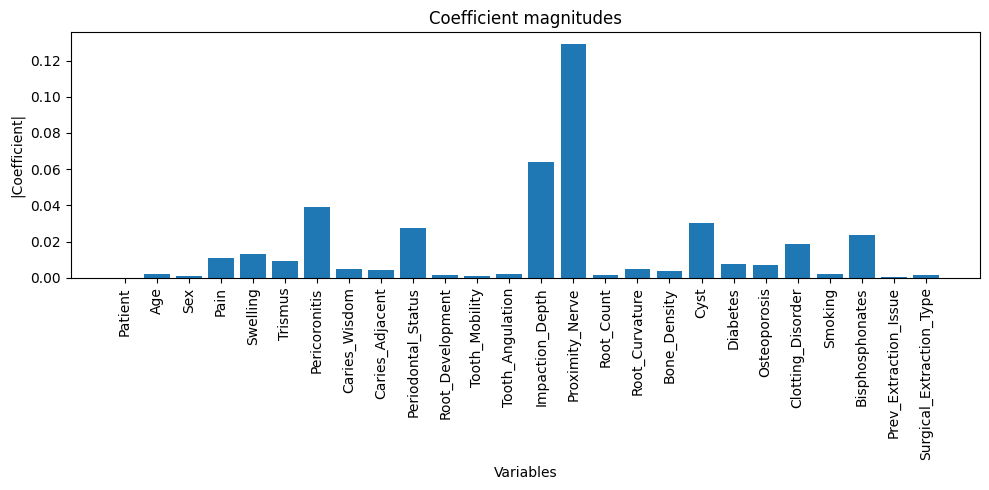

In [106]:
inter, coef = multiple_regression(df, variables)
plot_magnitude(coef, variables, title=f"Coefficient magnitudes")

# Multiple regression in FL

In [92]:
def FL_mul_reg(df, variables, num_clients, weighted = True):
    d = len(variables)
    k = num_clients
    n = len(df)
    all_coefs = np.zeros((k, d+2))
    for i in range(1, num_clients+1):
        client_data = df[df["Client"] == i]
        if len(client_data) > 0:
            inter, coefs = multiple_regression(client_data, variables)
            all_coefs[i-1, 0] = inter
            all_coefs[i-1, 1] = len(client_data)
            all_coefs[i-1, 2:] = coefs

    # vægtet gennemsnit
    if weighted:
        means_intercept = 0
        means_coefs = np.zeros(d)
        for i in range(k):
            means_intercept += all_coefs[i, 1] * all_coefs[i, 0]
        means_intercept /= n
        for i in range(d):
            for j in range(k):
                means_coefs[i] += all_coefs[j, 1] * all_coefs[j, i+2]
            means_coefs[i] /= n

    # det simple ikke-vægtede gennemsnit
    if not weighted:
        means_intercept = np.mean(all_coefs[:, 0])
        means_coefs = np.mean(all_coefs[:, 2:], axis=0)

    return means_intercept, means_coefs

        

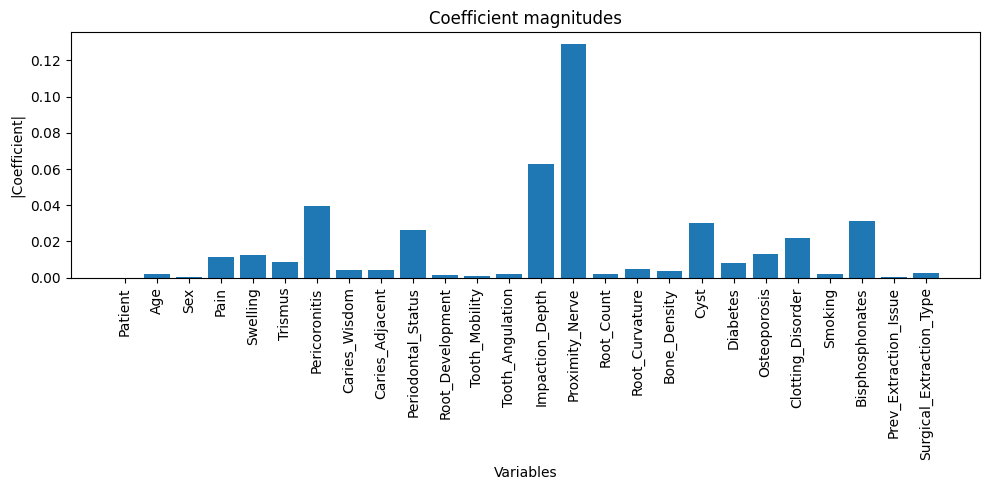

In [108]:
co = FL_mul_reg(df, variables, 10)
coefs = co[1]
plot_magnitude(coefs, variables, title=f"Coefficient magnitudes")

## One regression for each complication

In [94]:
variables = df.columns[1:27].tolist()

def multiple_regression_foreach(df,complication, variables):
    '''
    Input: df (dataframe), variables (all the variables you want to include in the regression as a list)
    Returns: (intercept, [list of coefficients])
    '''
    n = len(df)
    d = len(variables)

    # construct empty design matrix
    X = np.zeros((n, d))

    # targets
    y = df[complication]

    # fill out design matrix 
    for i in range(d):
        X[:, i] = df[variables[i]]
    
    #make model
    model = lr()
    #fit model
    model.fit(X,  y)
    return model.intercept_, model.coef_

def FL_mul_reg_foreach(df, variables,complication, num_clients, weighted = True):
    d = len(variables)
    k = num_clients
    n = len(df)
    all_coefs = np.zeros((k, d+2))
    for i in range(1, num_clients+1):
        client_data = df[df["Client"] == i]
        if len(client_data) > 0:
            inter, coefs = multiple_regression_foreach(client_data,complication, variables)
            all_coefs[i-1, 0] = inter
            all_coefs[i-1, 1] = len(client_data)
            all_coefs[i-1, 2:] = coefs

    # vægtet gennemsnit
    if weighted:
        means_intercept = 0
        means_coefs = np.zeros(d)
        for i in range(k):
            means_intercept += all_coefs[i, 1] * all_coefs[i, 0]
        means_intercept /= n
        for i in range(d):
            for j in range(k):
                means_coefs[i] += all_coefs[j, 1] * all_coefs[j, i+2]
            means_coefs[i] /= n

    # det simple ikke-vægtede gennemsnit
    if not weighted:
        means_intercept = np.mean(all_coefs[:, 0])
        means_coefs = np.mean(all_coefs[:, 2:], axis=0)

    return means_intercept, means_coefs


def foreach(df, variables, num_clients, complications):
    result = {}
    for complication in complications:
        intercept, coefs = FL_mul_reg_foreach(df, variables,complication, num_clients, weighted = True)
        result[complication] = (intercept, coefs)
    return result

In [95]:
import numpy as np
import pandas as pd

def predict_from_coefs(df, variables, intercept, coefs):
    """
    Beregner y-hat = intercept + X beta
    for alle rækker i df.
    """
    X = df[variables].to_numpy()
    y_hat = intercept + X @ coefs
    return y_hat

def assign_tertiles(y_hat):
    """
    Deler y_hat i 3 grupper baseret på 1/3 og 2/3 kvantiler.
    Returnerer både gruppe-labels og grænserne.
    """
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2

def predict_and_group_all(test_df, variables, model_results):
    """
    model_results er fx output fra:
        results = foreach(df, variables, num_clients, complications)

    Returnerer et dataframe med predictions og gruppeinddeling
    for hver complication.
    """
    out = test_df.copy()
    cutoffs = {}

    for complication, (intercept, coefs) in model_results.items():
        y_hat = predict_from_coefs(test_df, variables, intercept, coefs)
        groups, q1, q2 = assign_tertiles(y_hat)

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs



In [96]:
test_data = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv")

complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

variables = df.columns[1:27].tolist()

results = foreach(df, variables, 10, complications)

test_with_preds, cutoffs = predict_and_group_all(test_data, variables, results)


In [97]:
import numpy as np
import pandas as pd

def metrics_for_one_complication(df, complication):
    """
    complication fx 'Risk_AlveolarOsteitis'
    
    Bruger:
      true: Risk_Category_AlveolarOsteitis
      pred: Risk_AlveolarOsteitis_group
    """
    
    true_col = complication.replace("Risk_", "Risk_Category_", 1)
    pred_col = f"{complication}_group"
    
    y_true = df[true_col].to_numpy()
    y_pred = df[pred_col].to_numpy()
    
    results = {}
    
    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
    
    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])
    
    return {
        "true_col": true_col,
        "pred_col": pred_col,
        "per_class": results,
        "macro_f1": macro_f1
    }

def metrics_for_all_complications(df, complications):
    all_results = {}
    macro_f1s = []

    for complication in complications:
        res = metrics_for_one_complication(df, complication)
        all_results[complication] = res
        macro_f1s.append(res["macro_f1"])

    # svarer til f1_global_macro i din pipeline
    overall_macro_f1 = np.mean(macro_f1s)

    return all_results, overall_macro_f1

In [98]:
complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

results, overall_f1 = metrics_for_all_complications(test_with_preds, complications)

for complication, res in results.items():
    print(f"\n--- {complication} ---")
    print(f"True column: {res['true_col']}")
    print(f"Pred column: {res['pred_col']}")
    
    for cls in [0, 1, 2]:
        vals = res["per_class"][cls]
        print(
            f"Class {cls}: "
            f"Precision={vals['precision']:.3f}, "
            f"Recall={vals['recall']:.3f}, "
            f"F1={vals['f1']:.3f}"
        )
    
    print(f"Macro F1 = {res['macro_f1']:.3f}")

print("\n==============================")
print(f"FINAL F1 (mean over risks) = {overall_f1:.3f}")
print("==============================")


--- Risk_AlveolarOsteitis ---
True column: Risk_Category_AlveolarOsteitis
Pred column: Risk_AlveolarOsteitis_group
Class 0: Precision=0.783, Recall=0.793, F1=0.788
Class 1: Precision=0.520, Recall=0.518, F1=0.519
Class 2: Precision=0.698, Recall=0.692, F1=0.695
Macro F1 = 0.667

--- Risk_SecondaryInfection ---
True column: Risk_Category_SecondaryInfection
Pred column: Risk_SecondaryInfection_group
Class 0: Precision=0.736, Recall=0.771, F1=0.753
Class 1: Precision=0.554, Recall=0.562, F1=0.558
Class 2: Precision=0.783, Recall=0.739, F1=0.761
Macro F1 = 0.690

--- Risk_NerveDysesthesia ---
True column: Risk_Category_NerveDysesthesia
Pred column: Risk_NerveDysesthesia_group
Class 0: Precision=0.793, Recall=0.805, F1=0.799
Class 1: Precision=0.569, Recall=0.567, F1=0.568
Class 2: Precision=0.754, Recall=0.745, F1=0.750
Macro F1 = 0.706

--- Risk_Bleeding ---
True column: Risk_Category_Bleeding
Pred column: Risk_Bleeding_group
Class 0: Precision=0.534, Recall=0.622, F1=0.575
Class 1: Prec

## Centralized

In [99]:
from sklearn.linear_model import LinearRegression as lr
import numpy as np
import pandas as pd


def fit_centralized_models(train_df, variables, complications):
    """
    Fitter én lineær regression pr. complication.
    """
    models = {}

    n = len(train_df)
    d = len(variables)

    X_train = np.zeros((n, d))
    for i in range(d):
        X_train[:, i] = train_df[variables[i]]

    for complication in complications:
        y_train = train_df[complication].to_numpy()

        model = lr()
        model.fit(X_train, y_train)

        models[complication] = {
            "intercept": model.intercept_,
            "coef": model.coef_
        }

    return models


def predict_and_group_centralized(test_df, variables, models):
    """
    Laver predictions og kvatil-grupper for hver complication på test_df.
    
    Tilføjer for hver complication:
      - Risk_XXX_group
    
    Returnerer:
      out_df, cutoffs
    """
    out = test_df.copy()
    cutoffs = {}

    n = len(test_df)
    d = len(variables)

    X_test = np.zeros((n, d))
    for i in range(d):
        X_test[:, i] = test_df[variables[i]]

    for complication, params in models.items():
        intercept = params["intercept"]
        coefs = params["coef"]

        y_hat = intercept + X_test @ coefs

        q1 = np.quantile(y_hat, 1/3)
        q2 = np.quantile(y_hat, 2/3)

        groups = np.where(
            y_hat <= q1, 0,
            np.where(y_hat <= q2, 1, 2)
        )

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs


def run_centralized_baseline(train_df, test_df, variables, complications):
    """
    Samlet pipeline:
      1. fit modeller på train
      2. predict + group på test
      3. beregn F1 med dine eksisterende metric-funktioner
    
    Returnerer en dictionary med alt relevant output.
    """
    models = fit_centralized_models(train_df, variables, complications)
    test_with_preds, cutoffs = predict_and_group_centralized(test_df, variables, models)
    results, overall_macro_f1 = metrics_for_all_complications(test_with_preds, complications)

    return {
        "models": models,
        "test_with_preds": test_with_preds,
        "cutoffs": cutoffs,
        "results": results,
        "overall_macro_f1": overall_macro_f1
    }




complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

variables = df.columns[1:27].tolist()

centralized_output = run_centralized_baseline(
    train_df=df,
    test_df=test_data,
    variables=variables,
    complications=complications
)

results = centralized_output["results"]
overall_f1 = centralized_output["overall_macro_f1"]
test_with_preds_centralized = centralized_output["test_with_preds"]

for complication, res in results.items():
    print(f"\n--- {complication} ---")
    print(f"True column: {res['true_col']}")
    print(f"Pred column: {res['pred_col']}")

    for cls in [0, 1, 2]:
        vals = res["per_class"][cls]
        print(
            f"Class {cls}: "
            f"Precision={vals['precision']:.3f}, "
            f"Recall={vals['recall']:.3f}, "
            f"F1={vals['f1']:.3f}"
        )

    print(f"Macro F1 = {res['macro_f1']:.3f}")

print("\n==============================")
print(f"CENTRALIZED FINAL F1 = {overall_f1:.3f}")
print("==============================")


--- Risk_AlveolarOsteitis ---
True column: Risk_Category_AlveolarOsteitis
Pred column: Risk_AlveolarOsteitis_group
Class 0: Precision=0.784, Recall=0.794, F1=0.789
Class 1: Precision=0.523, Recall=0.521, F1=0.522
Class 2: Precision=0.697, Recall=0.691, F1=0.694
Macro F1 = 0.668

--- Risk_SecondaryInfection ---
True column: Risk_Category_SecondaryInfection
Pred column: Risk_SecondaryInfection_group
Class 0: Precision=0.742, Recall=0.777, F1=0.759
Class 1: Precision=0.555, Recall=0.563, F1=0.559
Class 2: Precision=0.783, Recall=0.739, F1=0.761
Macro F1 = 0.693

--- Risk_NerveDysesthesia ---
True column: Risk_Category_NerveDysesthesia
Pred column: Risk_NerveDysesthesia_group
Class 0: Precision=0.792, Recall=0.804, F1=0.798
Class 1: Precision=0.570, Recall=0.568, F1=0.569
Class 2: Precision=0.749, Recall=0.740, F1=0.745
Macro F1 = 0.704

--- Risk_Bleeding ---
True column: Risk_Category_Bleeding
Pred column: Risk_Bleeding_group
Class 0: Precision=0.569, Recall=0.663, F1=0.612
Class 1: Prec

MLP F1 macro aggregated: 0.6946, 0.7161 efter mlp update.

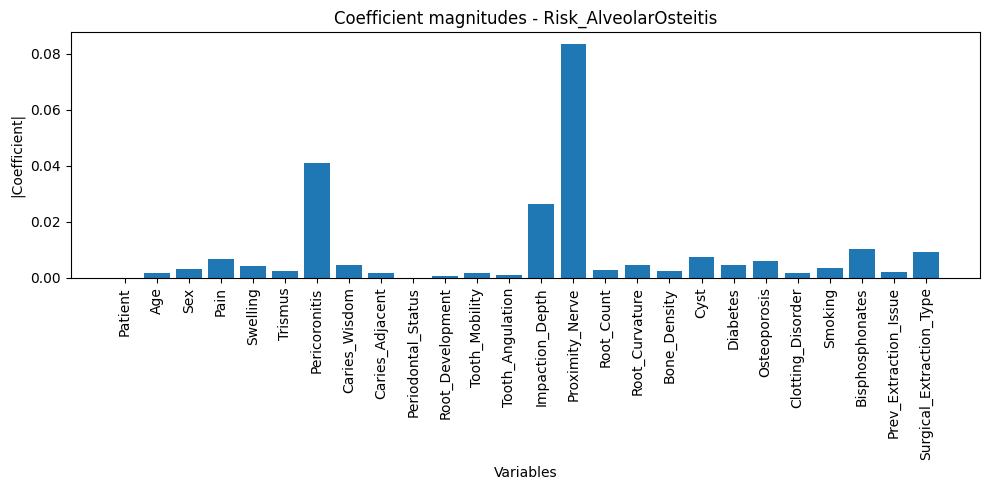

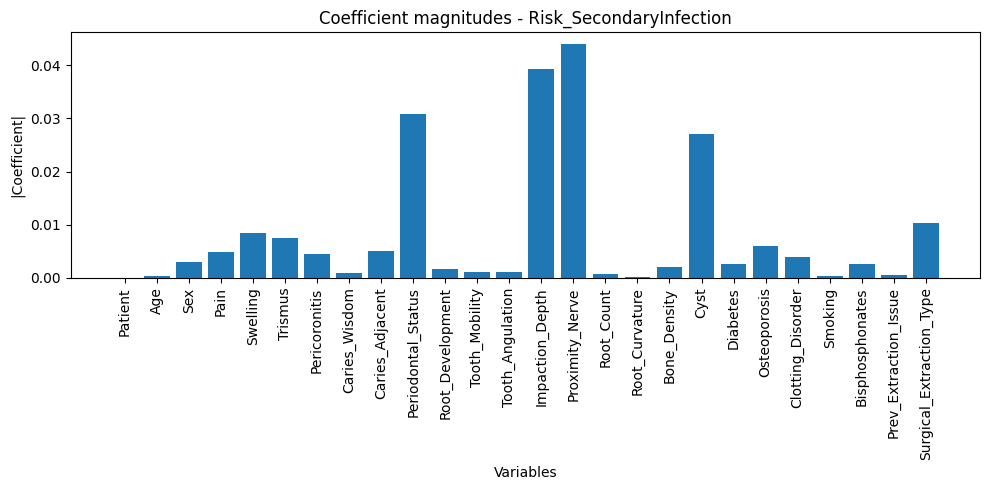

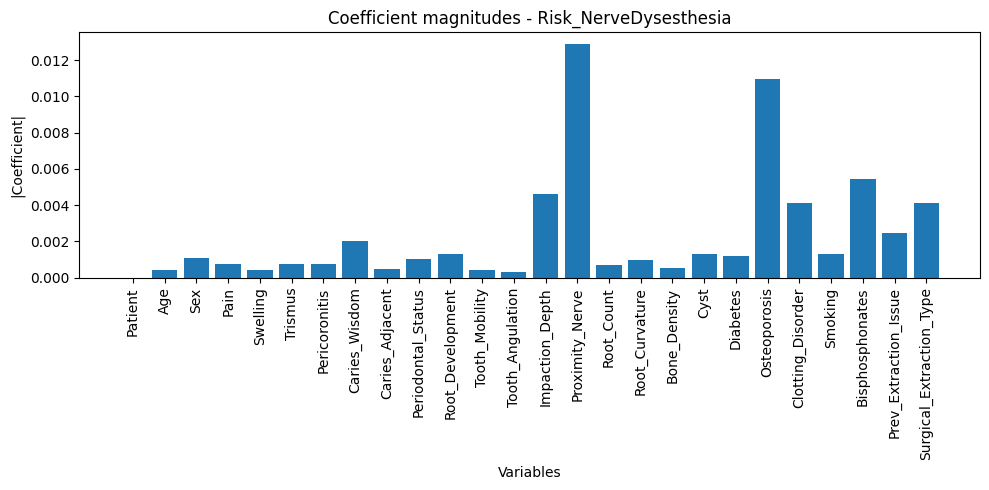

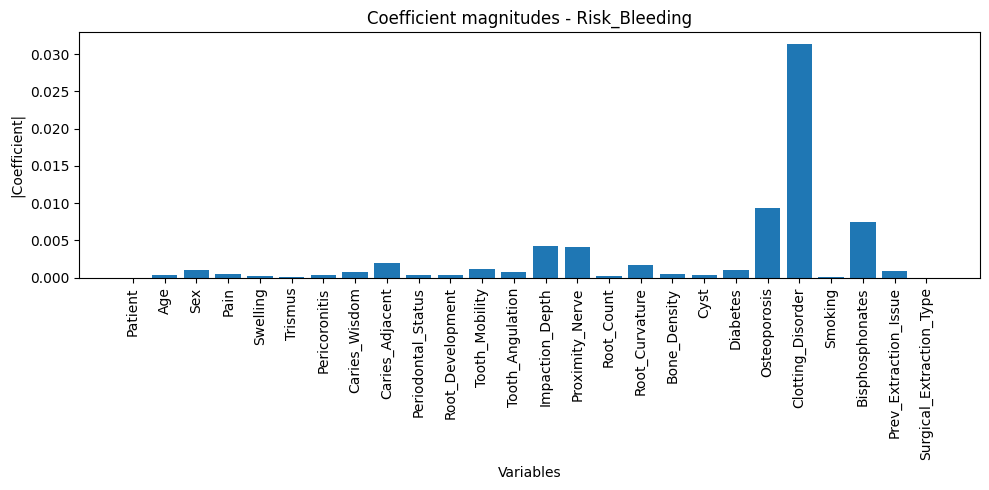

In [113]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_complications(results, variables):
    for complication, (intercept, coefs) in results.items():
        plot_magnitude(
            coefs,
            variables,
            title=f"Coefficient magnitudes - {complication}"
            )


results_fed = foreach(df, variables, 10, complications)
plot_all_complications(results_fed, variables)


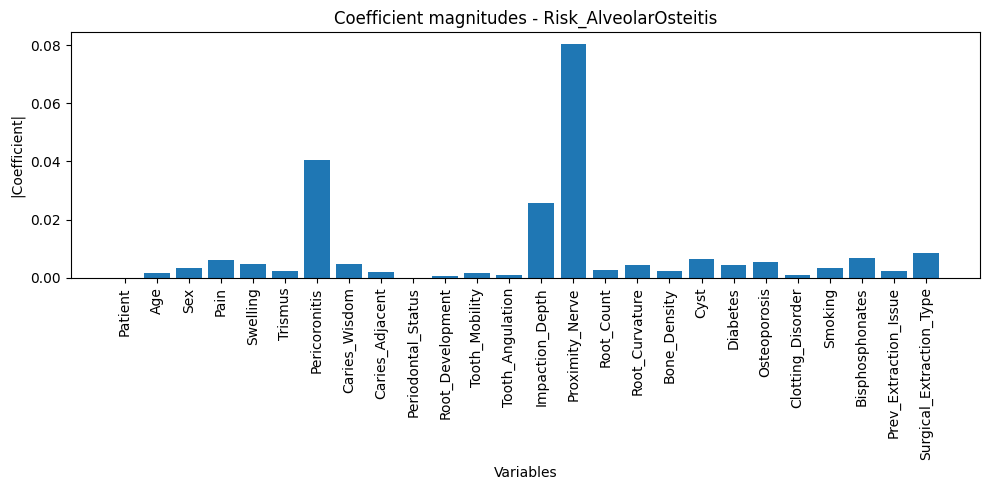

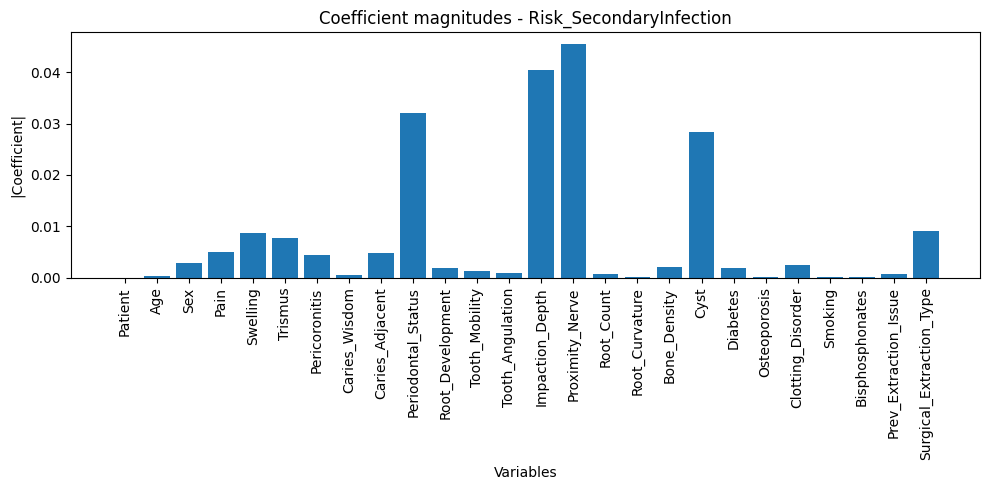

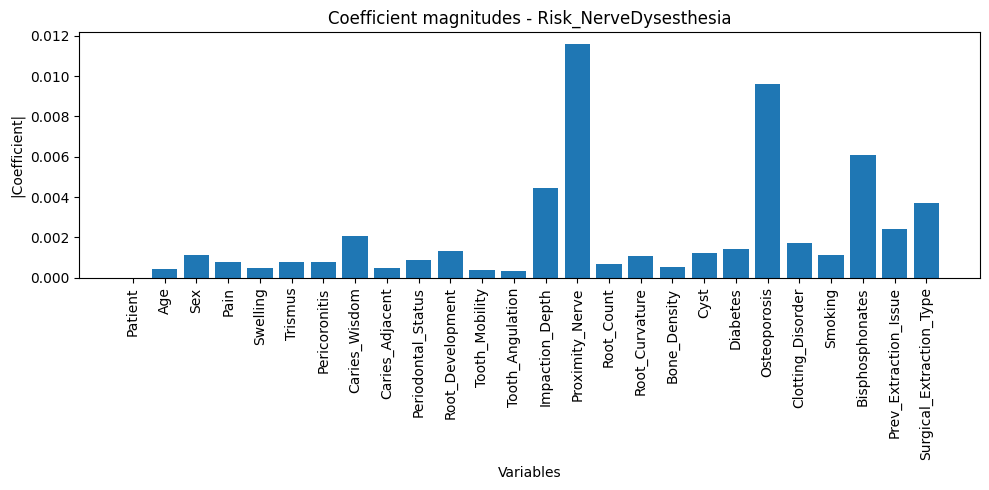

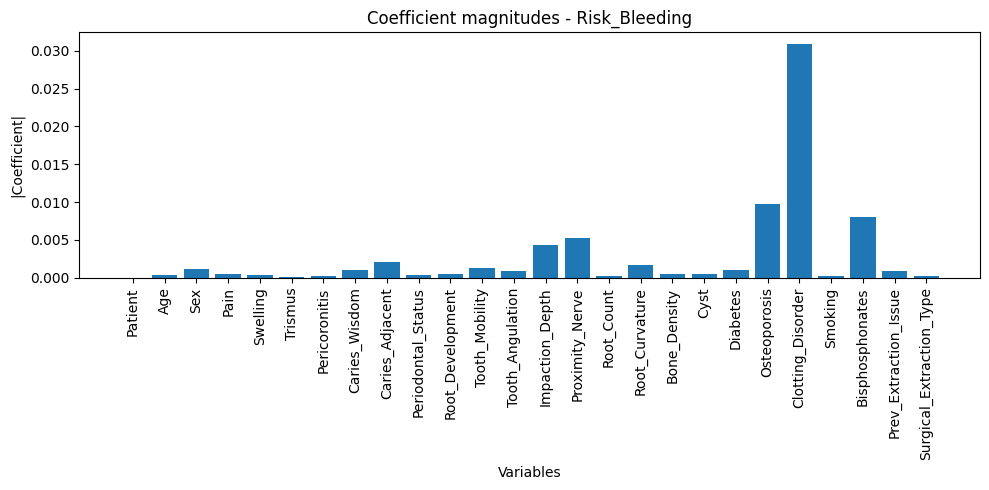

In [142]:

complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

variables = df.columns[1:27].tolist()

centralized_output = run_centralized_baseline(
    train_df=df,
    test_df=test_data,
    variables=variables,
    complications=complications
)

results_centralized = centralized_output["models"]

def plot_all_complications(results, variables):
    for complication, result_dict in results.items():
        plot_magnitude(
            result_dict["coef"],
            variables,
            title=f"Coefficient magnitudes - {complication}"
        )
plot_all_complications(results_centralized, variables)


Spørgsmål til ruben: hver komplication ligner at focusere på forskellige feachures, burde dette ikke afspejles bedre i vores MLP setup. Ligenu kører vi med fully connedted lag.

Skal data normilaseres